## Data loading & imports

In [2]:
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
data_path = './data/'
books = pd.read_csv(data_path + 'Books.csv')
ratings = pd.read_csv(data_path + 'Ratings.csv')
users = pd.read_csv(data_path + 'Users.csv')

C:\Users\Alex\AppData\Local\Temp\ipykernel_8744\4170505340.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(data_path + 'Books.csv')


## Data Analysis and Cleaning

In [4]:
len(books)

271360

In [5]:
books.isna().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [6]:
books.dropna(inplace=True)
books.drop(columns=['Image-URL-S', 'Image-URL-L'], inplace=True)

In [7]:
books['Year-Of-Publication'].dtype

dtype('O')

In [8]:
books['Year-Of-Publication'] = books['Year-Of-Publication'].astype('int')

In [9]:
books['Year-Of-Publication'].describe()

count    271353.000000
mean       1959.760235
std         257.996082
min           0.000000
25%        1989.000000
50%        1995.000000
75%        2000.000000
max        2050.000000
Name: Year-Of-Publication, dtype: float64

In [10]:
books['Decade'] = books['Year-Of-Publication'] // 10 * 10
books['Decade'].value_counts()

Decade
1990    126014
2000     72463
1980     52778
1970     12769
0         4618
1960      1773
1950       623
1940       127
1920        65
1930        57
1910        23
1900        17
2030         9
2020         6
2010         5
2050         2
1370         2
1800         1
1890         1
Name: count, dtype: int64

There are clearly some errors and missing values, but we won't fix this for now as won't affect our algorithm

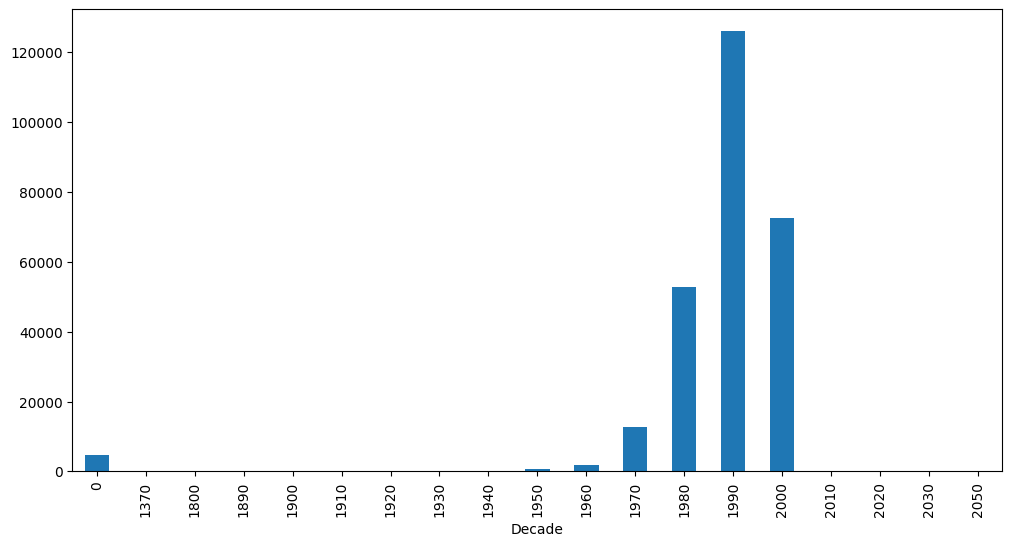

In [11]:
plt.figure(figsize=(12, 6))
books['Decade'].value_counts().sort_index().plot(kind='bar')
plt.show()

As we can see, the majority of books are published in 1950-2000. Let's take a look to the authors distribution

In [12]:
author_frequency = books['Book-Author'].value_counts()

<Axes: ylabel='Book-Author'>

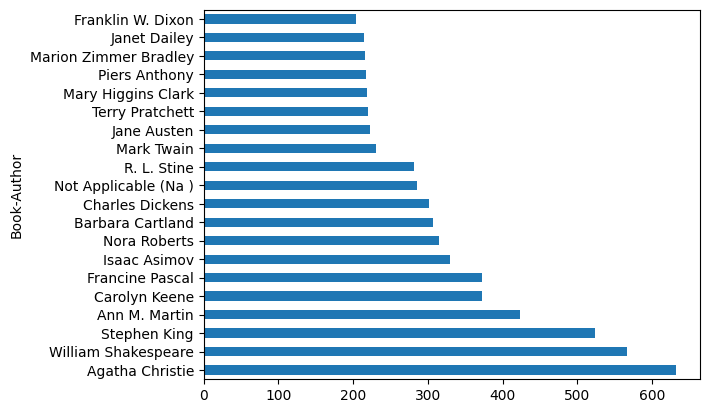

In [13]:
n_authors = 20
author_frequency.head(n_authors).plot(kind='barh')

Let's move on to the ratings dataframe

In [14]:
len(ratings)

1149780

In [15]:
ratings.isna().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [16]:
ratings

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


All values are from 0 to 10

In [17]:
ratings['Book-Rating'].describe()

count    1.149780e+06
mean     2.866950e+00
std      3.854184e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      7.000000e+00
max      1.000000e+01
Name: Book-Rating, dtype: float64

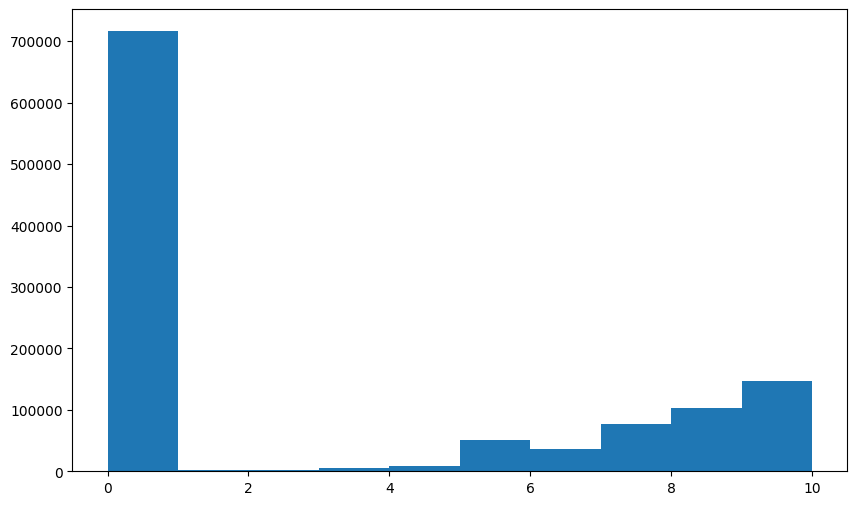

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(ratings['Book-Rating'])
plt.show()

We see that a lot of ratings are zero

In [19]:
user_ratings = ratings.groupby('User-ID').size()

In [20]:
r_user_ratings = pd.Series(user_ratings // 100 * 100)

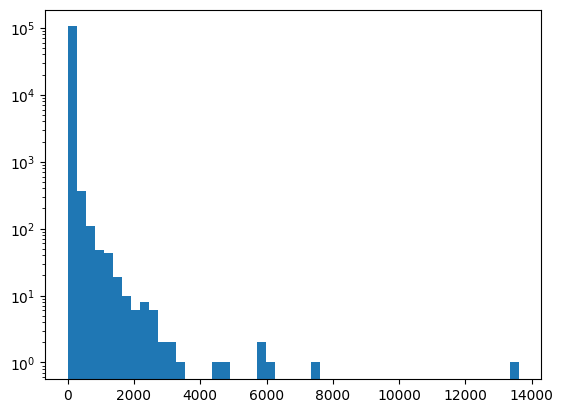

In [21]:
plt.hist(user_ratings, bins=50)
plt.yscale('log')
plt.show()

Take notice of a logarithmic scale. A lot of people left little number of reviews

In [22]:
len(user_ratings[user_ratings > 200])

899

In [23]:
book_ratings = ratings.groupby('ISBN').size()

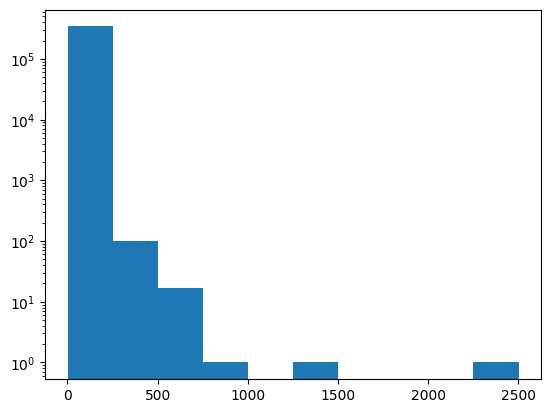

In [24]:
bq99 = book_ratings.quantile(0.99)
plt.hist(book_ratings)
plt.yscale('log')

The same situation is with the books ratings. most of the books received only a few reviews

In [25]:
len(book_ratings[book_ratings > 50])

2125

We don't need users dataframe, so skip straight to the model

## Collaborative filtering

We will create books-users table and represent each book as vector of user ratings. The algorithm will work only for books and users that have many ratings entries, so we will filter them

In [26]:
top_books = book_ratings[book_ratings > 50].index
top_users = user_ratings[user_ratings > 200].index
filtered_ratings = ratings[ratings['ISBN'].isin(top_books) & ratings['User-ID'].isin(top_users)]
book_user_table = filtered_ratings.pivot_table(index='ISBN', columns='User-ID', values='Book-Rating')
book_user_table.fillna(0, inplace=True)

In [27]:
from sklearn.metrics.pairwise import cosine_similarity

pairwise_sim = cosine_similarity(book_user_table)

In [28]:
def recommend(book_name: str, k: int=5) -> list[str]:
    match = books[books['Book-Title'] == book_name]
    if match.empty:
        print("Unknown book")
        return []
    
    id = match['ISBN'].iloc[0]
    if id not in book_user_table.index:
        print("This book has too little reviews")
        return []
    
    idx = np.where(book_user_table.index == id)[0][0]
    enum_sim = list(enumerate(pairwise_sim[idx]))
    sorted_sim = list(sorted(enum_sim, key=lambda x: x[1], reverse=True))
    neighbors = list(map(lambda x: x[0], sorted_sim[1:k+1]))
    neighbors_ids = book_user_table.index[neighbors]
    return books[books['ISBN'].isin(neighbors_ids)]['Book-Title'].tolist()

In [29]:
books.loc[books['ISBN'].isin(book_user_table.index)]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-M,Decade
18,0440234743,The Testament,John Grisham,1999,Dell,http://images.amazon.com/images/P/0440234743.0...,1990
19,0452264464,Beloved (Plume Contemporary Fiction),Toni Morrison,1994,Plume,http://images.amazon.com/images/P/0452264464.0...,1990
26,0971880107,Wild Animus,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.0...,2000
27,0345402871,Airframe,Michael Crichton,1997,Ballantine Books,http://images.amazon.com/images/P/0345402871.0...,1990
28,0345417623,Timeline,MICHAEL CRICHTON,2000,Ballantine Books,http://images.amazon.com/images/P/0345417623.0...,2000
...,...,...,...,...,...,...,...
58345,0140039589,Watership Down,Richard Adams,1974,Penguin Books,http://images.amazon.com/images/P/0140039589.0...,1970
60057,0061092886,The Fallen Man (Joe Leaphorn Novels),Tony Hillerman,1997,HarperTorch,http://images.amazon.com/images/P/0061092886.0...,1990
62414,0553575090,Deception on His Mind,ELIZABETH GEORGE,1998,Bantam,http://images.amazon.com/images/P/0553575090.0...,1990
70583,067155302X,Harvest,Tess Gerritsen,1997,Pocket,http://images.amazon.com/images/P/067155302X.0...,1990


In [30]:
lst = [
    'To Kill a Mockingbird', 
    'New Vegetarian: Bold and Beautiful Recipes for Every Occasion', 
    'Rich Dad, Poor Dad: What the Rich Teach Their Kids About Money--That the Poor and Middle Class Do Not!', 
    'The Catcher in the Rye',
    'The Girl Who Loved Tom Gordon',
    'One Hundred Years of Solitude',
    'The Hitchhiker\'s Guide to the Galaxy',
    'Bridget Jones\'s Diary',
    'Pride and Prejudice (Dover Thrift Editions)',
    'The Martian Chronicles',
    'The Cat Who Came to Breakfast (Cat Who... (Hardcover))',
    'Postmortem (Kay Scarpetta Mysteries (Paperback))',
    'Chicken Soup for the Soul (Chicken Soup for the Soul)',
    'Life of Pi',
    'The Alibi',
    'Harry Potter and the Chamber of Secrets (Book 2)'
]

Let's check how our model performs on chosen books

In [31]:
for s in lst:
    print("Recommendation for", s)
    print(recommend(s))
    print()

Recommendation for To Kill a Mockingbird
['The Catcher in the Rye', 'Lord of the Flies', 'Children of Dune (Dune Chronicles, Book 3)', 'A Separate Peace', 'Drowning Ruth']

Recommendation for New Vegetarian: Bold and Beautiful Recipes for Every Occasion
This book has too little reviews
[]

Recommendation for Rich Dad, Poor Dad: What the Rich Teach Their Kids About Money--That the Poor and Middle Class Do Not!
['The Four Agreements: A Practical Guide to Personal Freedom', 'Resistance : A Novel', 'Conversations with God : An Uncommon Dialogue (Book 1)', 'Escape the Night', 'Sushi for Beginners']

Recommendation for The Catcher in the Rye
['To Kill a Mockingbird', 'The Grapes of Wrath: John Steinbeck Centennial Edition (1902-2002)', '1984', 'My Point...And I Do Have One', 'Candide (Penguin Classics)']

Recommendation for The Girl Who Loved Tom Gordon
['The Bachman Books: Rage, the Long Walk, Roadwork, the Running Man', 'The Regulators', 'From a Buick 8', 'The Regulators', 'Pet Sematary']
